In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image


In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir, categories, transform=None):
        self.data = []
        self.transform = transform

        for cat in categories:
            label = 0 if cat.lower() == "original" else 1
            folder_path = os.path.join(root_dir, cat)
            video_folders = os.listdir(folder_path)

            for vid in tqdm(video_folders, desc=f"Loading {cat}"):
                vid_path = os.path.join(folder_path, vid)
                if not os.path.isdir(vid_path):
                    continue
                for img_path in glob(os.path.join(vid_path, "*.jpg")) + glob(os.path.join(vid_path, "*.png")):
                    self.data.append((img_path, label))

        random.shuffle(self.data)
        print(f"✅ Total images loaded: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


In [ ]:
# Assuming DeepfakeDataset class is already defined as you provided earlier

# Setup dataset and transform
data_root = "/content/drive/MyDrive/DeepfakeDataset/FaceForensics_Frames"
categories = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures", "original"]

train_ratio, val_ratio, test_ratio = 0.35, 0.05, 0.1  # Train ratio updated to 0.35
batch_size = 32

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Initialize dataset
dataset = DeepfakeDataset(data_root, categories, transform)

# Split dataset
train_size = int(train_ratio * len(dataset))
val_size = int(val_ratio * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

# Data loaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Loading original: 100%|██████████| 1000/1000 [01:01<00:00, 16.35it/s]


✅ Total images loaded: 7893
Using device: cuda


In [ ]:
def save_full_checkpoint(model, optimizer, history, model_name, epochs):
    checkpoint = {
        "model_name": model_name,
        "model": model,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "history": history,
        "epochs": epochs
    }

    filename = f"{model_name}_checkpoint.pth"
    torch.save(checkpoint, filename)

    print(f"💾 Full model + performance saved as: {filename}")


In [ ]:
def get_model(model_name, num_classes=2, pretrained=True):
    if model_name == 'mobilenetv2':
        model = models.mobilenet_v2(weights='IMAGENET1K_V1' if pretrained else None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == 'mobilenetv3large':
        model = models.mobilenet_v3_large(weights='IMAGENET1K_V1' if pretrained else None)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

    elif model_name == 'efficientnetb4':
        model = models.efficientnet_b4(weights='IMAGENET1K_V1' if pretrained else None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name=='efficientnetb0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    # ✅ IMPORTANT — move entire model to GPU AFTER modifying layers
    model = model.to(device)
    return model


In [ ]:
def plot_results(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 10))

    # Loss
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], label="Train Loss")
    plt.plot(epochs, history['val_loss'], label="Val Loss")
    plt.title(f"{model_name} — Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['train_acc'], label="Train Acc")
    plt.plot(epochs, history['val_acc'], label="Val Acc")
    plt.title(f"{model_name} — Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
def train_and_plot(model_name, model, train_loader, val_loader, epochs=20):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        # Training loop
        for imgs, labels in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = train_correct / len(train_loader.dataset)
        train_loss /= len(train_loader)

        # Validation loop
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_loss /= len(val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f" train loss: {train_loss:.4f} | Train Acc: {(train_acc*100):.2f}% | "
              f" Val loss: {val_loss:.4f}  | Val_Acc Acc: {(val_acc*100):.2f}% | ")

    # Plot training curves
    plot_results(history, model_name)

    # Save COMPLETE model + performance
    save_full_checkpoint(model, optimizer, history, model_name, epochs)

    print(f"✅ {model_name} training completed and fully saved!\n")


mobilenetv2 Epoch 1/20: 100%|██████████| 87/87 [00:25<00:00,  3.46it/s]


Epoch 1/20 |  train loss: 0.5827 | Train Acc: 68.10% |  Val loss: 0.5281  | Val_Acc Acc: 74.11% | 


mobilenetv2 Epoch 2/20: 100%|██████████| 87/87 [00:25<00:00,  3.41it/s]


Epoch 2/20 |  train loss: 0.3435 | Train Acc: 85.08% |  Val loss: 0.4800  | Val_Acc Acc: 78.93% | 


mobilenetv2 Epoch 3/20: 100%|██████████| 87/87 [00:24<00:00,  3.54it/s]


...

Epoch 18/20 |  train loss: 0.0213 | Train Acc: 99.38% |  Val loss: 0.8028  | Val_Acc Acc: 82.74% | 


mobilenetv2 Epoch 19/20: 100%|██████████| 87/87 [00:24<00:00,  3.54it/s]


Epoch 19/20 |  train loss: 0.0328 | Train Acc: 98.66% |  Val loss: 0.8267  | Val_Acc Acc: 78.68% | 


mobilenetv2 Epoch 20/20: 100%|██████████| 87/87 [00:24<00:00,  3.54it/s]


Epoch 20/20 |  train loss: 0.0237 | Train Acc: 99.13% |  Val loss: 0.6603  | Val_Acc Acc: 84.01% | 


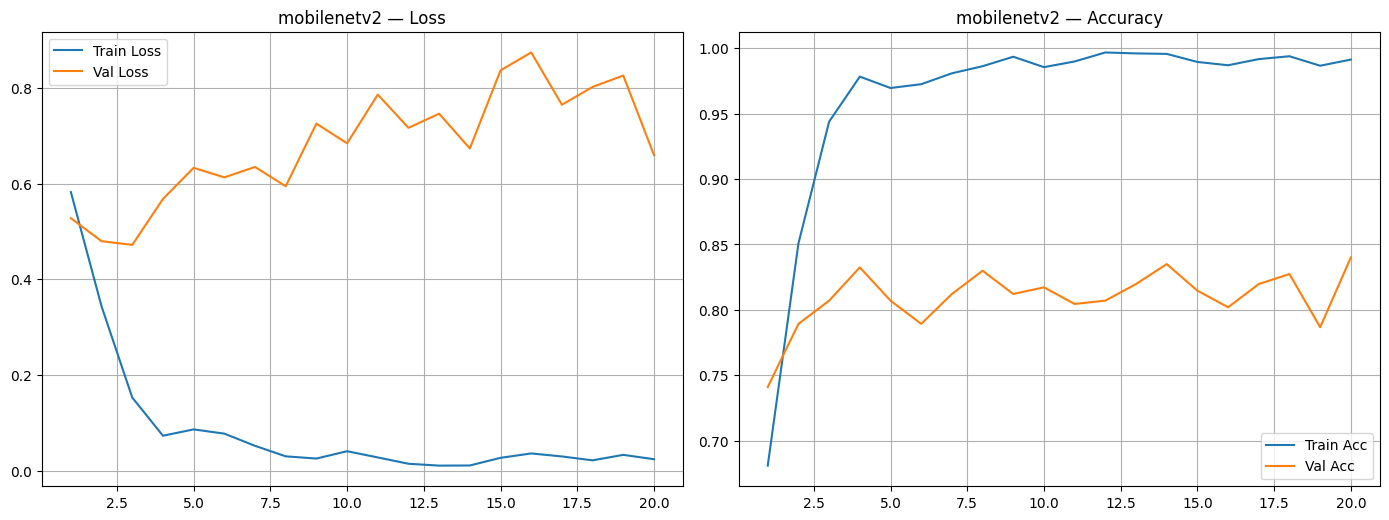

💾 Full model + performance saved as: mobilenetv2_checkpoint.pth
✅ mobilenetv2 training completed and fully saved!



In [ ]:
# Train and plot for MobileNetV2
model_name = 'mobilenetv2'
model = get_model(model_name)
train_and_plot(model_name, model, train_loader, val_loader, epochs=20)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 167MB/s]
mobilenetv3large Epoch 1/20: 100%|██████████| 87/87 [00:22<00:00,  3.85it/s]


Epoch 1/20 |  train loss: 0.6155 | Train Acc: 64.95% |  Val loss: 0.8800  | Val_Acc Acc: 53.55% | 


mobilenetv3large Epoch 2/20: 100%|██████████| 87/87 [00:22<00:00,  3.88it/s]


Epoch 2/20 |  train loss: 0.3676 | Train Acc: 83.38% |  Val loss: 0.7265  | Val_Acc Acc: 64.97% | 


...

Epoch 18/20 |  train loss: 0.0123 | Train Acc: 99.57% |  Val loss: 0.8017  | Val_Acc Acc: 78.93% | 


mobilenetv3large Epoch 19/20: 100%|██████████| 87/87 [00:22<00:00,  3.93it/s]


Epoch 19/20 |  train loss: 0.0080 | Train Acc: 99.75% |  Val loss: 0.7121  | Val_Acc Acc: 82.99% | 


mobilenetv3large Epoch 20/20: 100%|██████████| 87/87 [00:21<00:00,  4.01it/s]


Epoch 20/20 |  train loss: 0.0148 | Train Acc: 99.53% |  Val loss: 1.4151  | Val_Acc Acc: 76.14% | 


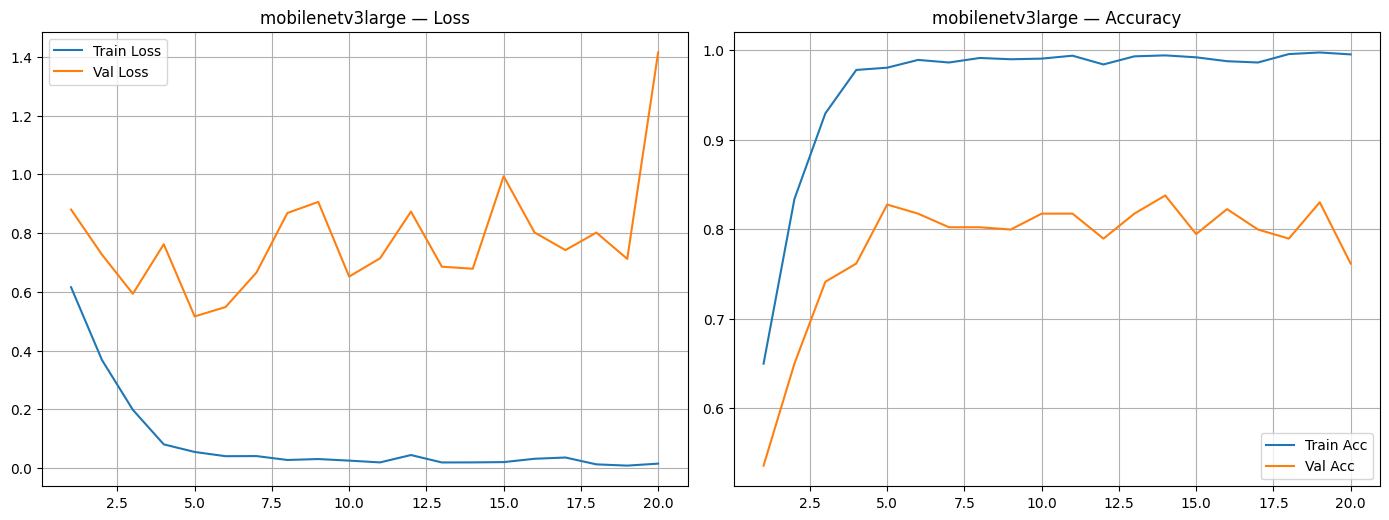

💾 Full model + performance saved as: mobilenetv3large_checkpoint.pth
✅ mobilenetv3large training completed and fully saved!



In [ ]:
# Train and plot for MobileNetV3Large
model_name = 'mobilenetv3large'
model = get_model(model_name)
train_and_plot(model_name, model, train_loader, val_loader, epochs=20)


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 185MB/s]
efficientnetb4 Epoch 1/20: 100%|██████████| 87/87 [00:52<00:00,  1.65it/s]


Epoch 1/20 |  train loss: 0.6887 | Train Acc: 54.27% |  Val loss: 0.6844  | Val_Acc Acc: 57.36% | 


efficientnetb4 Epoch 2/20: 100%|██████████| 87/87 [00:52<00:00,  1.67it/s]


Epoch 2/20 |  train loss: 0.6652 | Train Acc: 62.31% |  Val loss: 0.6641  | Val_Acc Acc: 62.18% | 


...

Epoch 18/20 |  train loss: 0.0460 | Train Acc: 98.55% |  Val loss: 0.7746  | Val_Acc Acc: 79.19% | 


efficientnetb4 Epoch 19/20: 100%|██████████| 87/87 [00:51<00:00,  1.67it/s]


Epoch 19/20 |  train loss: 0.0355 | Train Acc: 98.66% |  Val loss: 0.7618  | Val_Acc Acc: 78.17% | 


efficientnetb4 Epoch 20/20: 100%|██████████| 87/87 [00:51<00:00,  1.68it/s]


Epoch 20/20 |  train loss: 0.0426 | Train Acc: 98.70% |  Val loss: 0.7745  | Val_Acc Acc: 77.92% | 


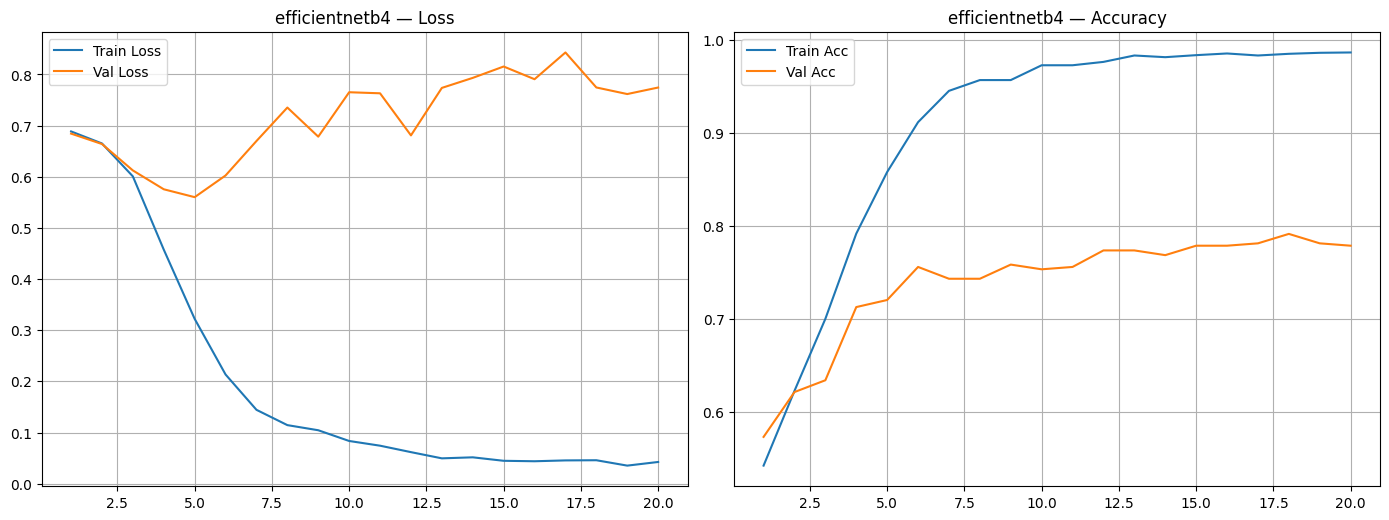

💾 Full model + performance saved as: efficientnetb4_checkpoint.pth
✅ efficientnetb4 training completed and fully saved!



In [ ]:
# Train and plot for EfficientNetB4
model_name = 'efficientnetb4'
model = get_model(model_name)
train_and_plot(model_name, model, train_loader, val_loader, epochs=20)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]
resnet50 Epoch 1/20: 100%|██████████| 87/87 [00:41<00:00,  2.08it/s]


Epoch 1/20 |  train loss: 0.5747 | Train Acc: 69.88% |  Val loss: 0.5317  | Val_Acc Acc: 76.14% | 


resnet50 Epoch 2/20: 100%|██████████| 87/87 [00:41<00:00,  2.11it/s]


Epoch 2/20 |  train loss: 0.2413 | Train Acc: 90.44% |  Val loss: 0.5444  | Val_Acc Acc: 79.70% | 


...

Epoch 18/20 |  train loss: 0.0171 | Train Acc: 99.42% |  Val loss: 0.4947  | Val_Acc Acc: 87.31% | 


resnet50 Epoch 19/20: 100%|██████████| 87/87 [00:41<00:00,  2.12it/s]


Epoch 19/20 |  train loss: 0.0141 | Train Acc: 99.67% |  Val loss: 0.5741  | Val_Acc Acc: 84.01% | 


resnet50 Epoch 20/20: 100%|██████████| 87/87 [00:41<00:00,  2.11it/s]


Epoch 20/20 |  train loss: 0.0156 | Train Acc: 99.38% |  Val loss: 0.5410  | Val_Acc Acc: 82.99% | 


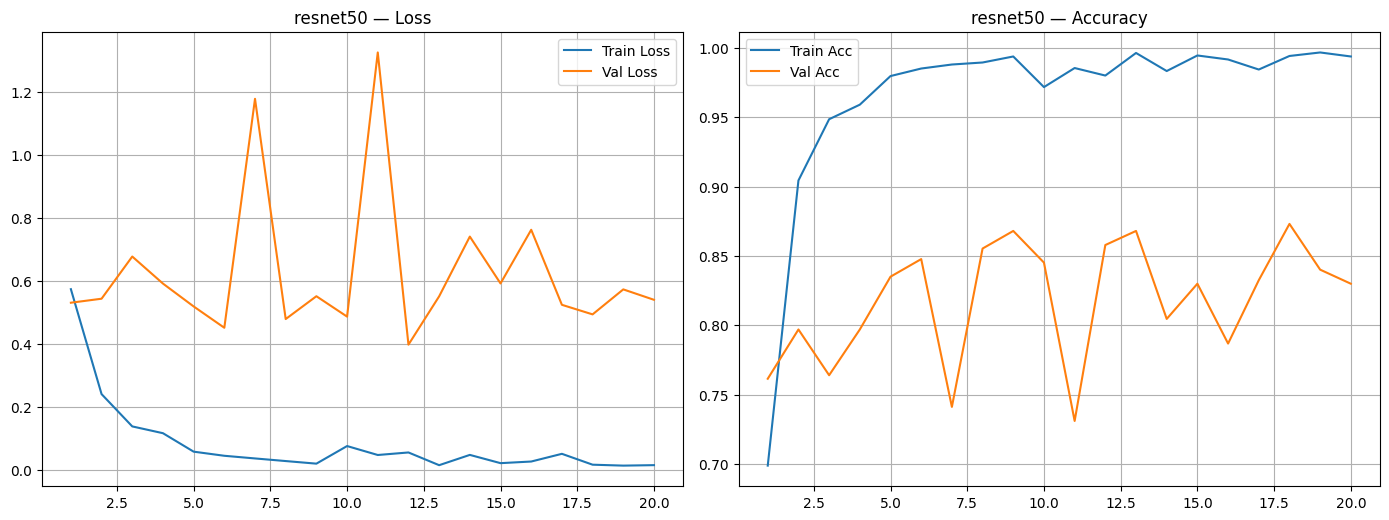

💾 Full model + performance saved as: resnet50_checkpoint.pth
✅ resnet50 training completed and fully saved!



In [ ]:
# Train and plot for ResNet50
model_name = 'resnet50'
model = get_model(model_name)
train_and_plot(model_name, model, train_loader, val_loader, epochs=20)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]
efficientnetb0 Epoch 1/20: 100%|██████████| 87/87 [00:28<00:00,  3.09it/s]


Epoch 1/20 |  train loss: 0.6174 | Train Acc: 65.39% |  Val loss: 0.5428  | Val_Acc Acc: 71.07% | 


efficientnetb0 Epoch 2/20: 100%|██████████| 87/87 [00:27<00:00,  3.11it/s]


Epoch 2/20 |  train loss: 0.4156 | Train Acc: 81.46% |  Val loss: 0.4489  | Val_Acc Acc: 79.44% | 


...

Epoch 18/20 |  train loss: 0.0267 | Train Acc: 99.13% |  Val loss: 0.5278  | Val_Acc Acc: 84.26% | 


efficientnetb0 Epoch 19/20: 100%|██████████| 87/87 [00:27<00:00,  3.16it/s]


Epoch 19/20 |  train loss: 0.0185 | Train Acc: 99.46% |  Val loss: 0.5737  | Val_Acc Acc: 83.76% | 


efficientnetb0 Epoch 20/20: 100%|██████████| 87/87 [00:27<00:00,  3.15it/s]


Epoch 20/20 |  train loss: 0.0192 | Train Acc: 99.35% |  Val loss: 0.5251  | Val_Acc Acc: 84.26% | 


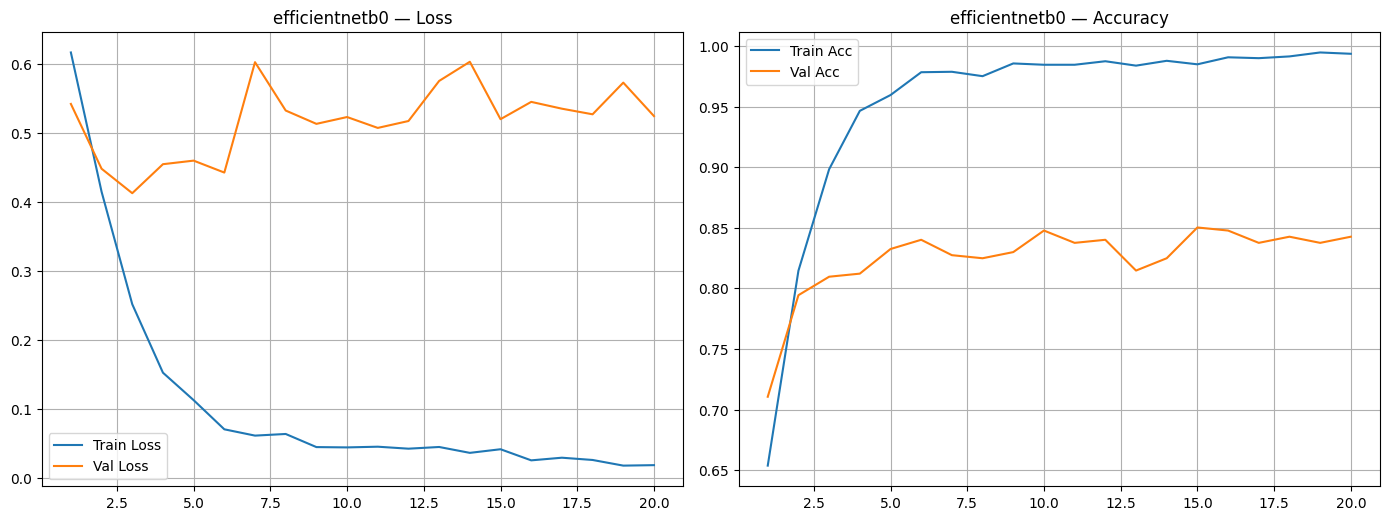

💾 Full model + performance saved as: efficientnetb0_checkpoint.pth
✅ efficientnetb0 training completed and fully saved!



In [ ]:
# Train and plot for EffientNetB0
model_name = 'efficientnetb0'
model = get_model(model_name)
train_and_plot(model_name, model, train_loader, val_loader, epochs=20)
